In [14]:
!pip install torch torchvision opencv-python matplotlib pillow

In [15]:
import torch
import torchvision
import cv2
import matplotlib.pyplot as plt
from PIL import Image

In [16]:
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(
    pretrained=True
)

model.eval()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

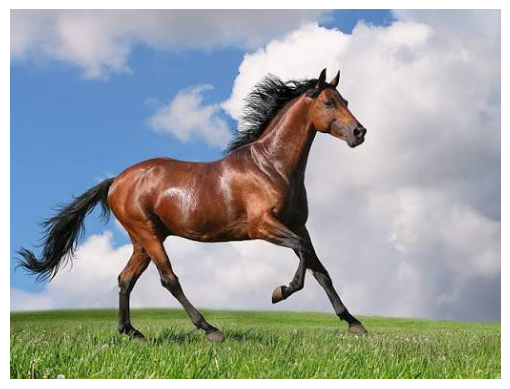

In [25]:
img = Image.open("/content/images.jpeg")

plt.imshow(img)
plt.axis("off")
plt.show()

In [26]:
transform = torchvision.transforms.ToTensor()

img_tensor = transform(img)

img_tensor.shape

torch.Size([3, 388, 515])

In [27]:
with torch.no_grad():
    prediction = model([img_tensor])

In [28]:
prediction[0].keys()

dict_keys(['boxes', 'labels', 'scores'])

In [29]:
boxes = prediction[0]['boxes']
labels = prediction[0]['labels']
scores = prediction[0]['scores']

print("Number of objects:", len(boxes))

Number of objects: 1


In [30]:
COCO_CLASSES = [
'__background__',
'person','bicycle','car','motorcycle','airplane','bus','train',
'truck','boat','traffic light','fire hydrant','stop sign',
'parking meter','bench','bird','cat','dog','horse','sheep',
'cow','elephant','bear','zebra','giraffe'
]

In [34]:
image = cv2.imread("/content/images.jpeg")

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

for box, label, score in zip(boxes, labels, scores):

    if score > 0.7:

        x1, y1, x2, y2 = box.int().tolist()

        cv2.rectangle(
            image,
            (x1, y1),
            (x2, y2),
            (255,0,0),
            2
        )

        class_name = COCO_CLASSES[label]

        cv2.putText(
            image,
            class_name,
            (x1, y1-10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (255,0,0),
            2
        )

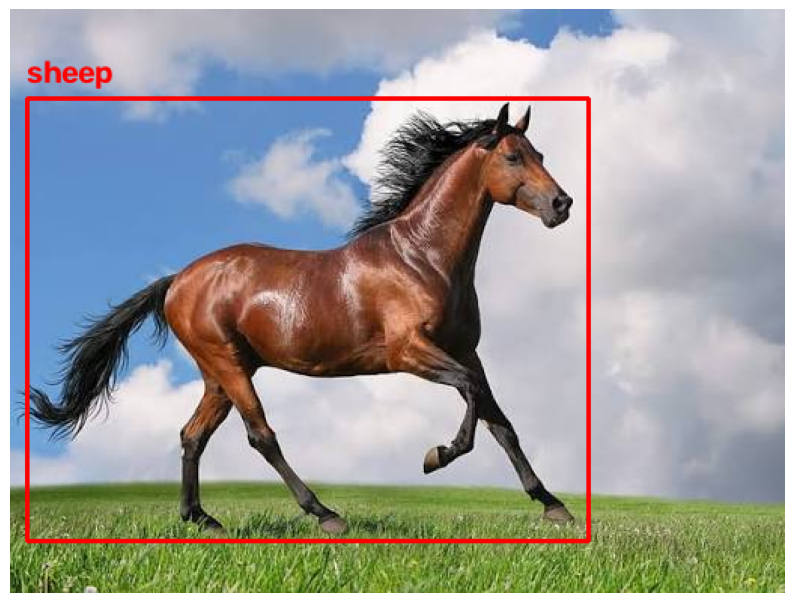

In [35]:
plt.figure(figsize=(10,8))

plt.imshow(image)

plt.axis("off")

plt.show()